In [1]:
# Set env vars for the relevant model or load from a .env file:
import dotenv
dotenv.load_dotenv()

True

## A multi-agent workflow using LangGraph
### Synopsis
Though AI is far from Skynet, it's powerful if you take the time to tell it what you want.</br>
In this case, using the LangGraph / LangChain libraries building something interesting doesn't take a ton of work. 
### Motivation
Social media is filled with  "gotcha posts" of users showing the results of seemingly clear Chat GPT queries which give nonsensical results. Though these posts help dispel some of the GenAI hype, they imply that the tool is not all that useful. In this case, I got some existing boilerplate code, made a few changes and here you go.

In [2]:
# --- cell 1: imports & initialization ---
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
from langgraph_supervisor import create_supervisor
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
# determine the type of GPU available
import torch
import uuid
from threading import Lock
from typing import Annotated, Union
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler
import PIL
from compel import CompelForSDXL
# Include tools used for the workflow
from local_tools import (
    get_device,
    pretty_print_messages,
)
import dotenv
import os

from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Could not find repo root (pyproject.toml not found).")

REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / "results" / "langGraph-alphabet"
# Make a directory to save the images
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Determine the type of GPU available
device = get_device()
# Set env vars for the relevant model or load from a .env file:
dotenv.load_dotenv()


# Use float16 for MPS and CUDA, float32 for CPU
dtype = torch.float16 if device in ("mps", "cuda") else torch.float32
print(f"Using {device=} {dtype=}")

# Define the Stable Diffusion pipeline
MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = StableDiffusionXLPipeline.from_pretrained(MODEL_ID, torch_dtype=dtype)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

# disable safety checker in a version-proof way (so there is no blacking-out of images when there is nothing inappropriate)
def _pass(images, *args, **kwargs): 
    return images, [False]*len(images)
pipe.safety_checker = _pass

# Helpful on Apple GPUs
pipe.enable_attention_slicing()
pipe.enable_vae_tiling()


# Initialize the LLM
llm = ChatOllama(model="gpt-oss:20b", temperature=0.2)


/opt/anaconda3/envs/ai_backup_py312/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
Using device=device(type='mps') dtype=torch.float32


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [3]:
# Helper functions
import os
def first_tool_call_only(ai_msg):
    calls = getattr(ai_msg, "tool_calls", None) or []
    if len(calls) <= 1:
        return ai_msg
    ai_msg.tool_calls = calls[:1]   # keep only the first
    return ai_msg


#       For image generation agent using stable diffusion or the dall-e-3.
def saveThumbnail(filename:str, thumbnail_filename:str, height:int=200, width:int=200)->str: 
    '''Create and save a thumbnail of an image'''
    img = PIL.Image.open(filename)
    img.thumbnail((width, height))
    if not thumbnail_filename.endswith(".png"):
        thumbnail_filename = f"{thumbnail_filename}.png"
    else:
        thumbnail_filename = '.'.join(thumbnail_filename.split('.')[:2])
    img.save(thumbnail_filename)
    return thumbnail_filename

def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f" {suffix}"
    )



In [4]:
import os, uuid
import torch
from langchain_core.tools import tool
from threading import Lock
from pydantic import BaseModel, Field

# Rules of thumb for image generation:
# SDXL was trained on 1024x1024 images, so it does best if the selection is 768x768 or 1024x1024. A smaller size make give funky results.
def _gen_one_image(
    *,
    pipe,
    noun: str,
    output_dir: str,
    steps: int,
    guidance: float,
    width: int,
    height: int,
    seed: int | None,
    filename_root: str,
) -> str:
    os.makedirs(output_dir, exist_ok=True)

    main_prompt = (
        f"A single {noun}, large in frame, centered, isolated cutout. "
        "Pure white seamless background, no texture. "
        "Children’s watercolor illustration, soft washes, visible paper grain on the subject only."
    )

    negative_prompt = (
        "background, scenery, landscape, horizon, environment, room, "
        "gradient background, colored background, vignette, shadow, spotlight, "
        "pattern, texture, wallpaper, bokeh"
    )

    gen = torch.Generator(device="cpu")
    if seed is not None:
        gen.manual_seed(int(seed))

    img = pipe(
        prompt=main_prompt,
        negative_prompt=negative_prompt,
        guidance_scale=guidance,
        num_inference_steps=steps,
        width=width,
        height=height,
        generator=gen,
    ).images[0]

    if not filename_root:
        filename_root = noun.replace("/", "_")

    out_path = output_dir / f"{filename_root}.png"
    img.save(out_path)

    # optional: thumbnail
    thumb = img.copy()
    thumb.thumbnail((256, 256))
    thumb.save(output_dir / f"{filename_root}_thumb.png")

    if getattr(pipe, "device", None) and pipe.device.type == "mps":
        torch.mps.empty_cache()

    return out_path


def make_genDiffuserImage_tool(pipe, *, output_dir=OUTPUT_DIR,
                               default_steps=25, default_guidance=6.0, default_size=(768,768)):
    lock = Lock()

    @tool
    def genDiffuserImage(
        noun: str,
        steps: int = default_steps,
        guidance: float = default_guidance,
        width: int = default_size[0],
        height: int = default_size[1],
        seed: int | None = None,
        filename_root: str = "",
    ) -> str:
        """Generate one image for a single noun."""
        with lock:
            return _gen_one_image(
                pipe=pipe,
                noun=noun,
                output_dir=output_dir,
                steps=steps,
                guidance=guidance,
                width=width,
                height=height,
                seed=seed,
                filename_root=filename_root or noun,
            )

    return genDiffuserImage


def make_genDiffuserImageBatch_tool(pipe, *, output_dir=OUTPUT_DIR,
                                    default_steps=25, default_guidance=6.0, default_size=(768,768)):
    lock = Lock()

    class BatchReq(BaseModel):
        nouns: list[str] = Field(..., description="List of nouns")
        seed: int = 1337
        steps: int = default_steps
        guidance: float = default_guidance
        width: int = default_size[0]
        height: int = default_size[1]
        filename_prefix: str = ""

    @tool(args_schema=BatchReq)
    def genDiffuserImageBatch(
        nouns: list[str],
        seed: int = 1337,
        steps: int = default_steps,
        guidance: float = default_guidance,
        width: int = default_size[0],
        height: int = default_size[1],
        filename_prefix: str = "",
    ) -> dict:
        """Generate one image per noun. Returns a small summary."""
        print(f"[BATCH] steps={steps} guidance={guidance} size={width}x{height}")
        paths = []
        with lock:
            for i, noun in enumerate(nouns):
                filename_prefix = f"{i:03d}_" #just make the files simple
                root = f"{filename_prefix}{noun}".replace(" ", "_")
                p = _gen_one_image(
                    pipe=pipe,
                    noun=noun,
                    output_dir=output_dir,
                    steps=steps,
                    guidance=guidance,
                    width=width,
                    height=height,
                    seed=seed + i,
                    filename_root=root,
                )
                paths.append(p)

        return {"count": len(paths), "sample_paths": paths[:5]}

    return genDiffuserImageBatch


#  search the web
@tool
def searchWeb(query: Annotated[str, "The search query."]):
    """Use this to search the web for recent information. 
    You should use this tool when you need to find information about current events, 
    or if you need to find information that is not in your training data.
    Input should be a search query."""
    try:
        web_search = TavilySearch(max_results=3)
        results = web_search.run(query)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return results

In [5]:
# Define agents
genDiffuserImageBatch = make_genDiffuserImageBatch_tool(pipe)
image_generation_agent = create_agent(
    model=llm,
    tools=[genDiffuserImageBatch],
    name="image_generation_agent",
    system_prompt=make_system_prompt(
        "You are an image generation agent.\n"
        "- ONLY generate images.\n"
        "- Call genDiffuserImageBatch ONCE with the nouns list.\n"
        "- ALWAYS call genDiffuserImageBatch with:"
        "  steps=25, guidance=6.5, width=768, height=768\n"
        "- Return ONLY the tool result."
    ),
)



# Research agent
research_agent = create_agent(
    model=llm,
    tools=[searchWeb],
    name="research_agent",
    system_prompt=make_system_prompt(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any chart generation\n"
        "- You have access to one tool: searchWeb. Use this tool to search the web for recent information based on the user's request.\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
)


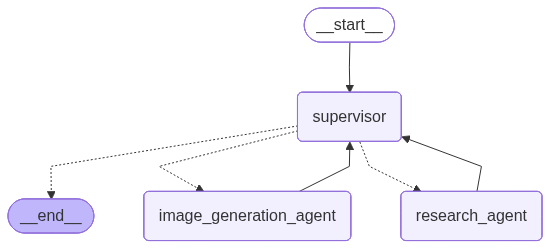

In [6]:
# Define supervisor and show graph
supervisor = create_supervisor(
    model=llm,
    agents=[research_agent, image_generation_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- research_agent: finds/returns data.\n"
        "- image_generation_agent: generates images using tools.\n\n"
        "Rules:\n"
        "- Call ONE agent at a time.\n"
        "- Do not solve the task yourself.\n"
        "- BEFORE calling transfer_to_<agent>, you MUST write a short message that starts with:\n"
        "  TASK: ...\n"
        "  INPUT: ...\n"
        "  OUTPUT FORMAT: ...\n"
        "- Keep TASK messages short and concrete.\n"
    ),
    add_handoff_back_messages=True,
    output_mode="last_message",
    include_agent_name="inline",   # important for non-OpenAI providers
).compile()

from IPython.display import display, Image
display(Image(supervisor.get_graph().draw_mermaid_png()))

In [7]:
for event in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": """
1. Have the research_agent list the names of 100 distinct common animals.
2. Have the image_generation_agent generate an image for each animal returned from the research_agent. Save the image as "{animal}.png".
3. When all images are generated, finish."""
            }
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 50},
):
    pretty_print_messages(event, last_message=True)
    print(event)


Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent


{'supervisor': {'messages': [HumanMessage(content='\n1. Have the research_agent list the names of 100 distinct common animals.\n2. Have the image_generation_agent generate an image for each animal returned from the research_agent. Save the image as "{animal}.png".\n3. When all images are generated, finish.', additional_kwargs={}, response_metadata={}, id='9c48adb7-59e3-44ed-a05d-30b069c24f34'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-28T17:45:22.114739Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12394556542, 'load_duration': 5867750250, 'prompt_eval_count': 282, 'prompt_eval_duration': 1836557792, 'eval_count': 307, 'eval_duration': 4549076963, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, name='supervis

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Update from node image_generation_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


{'image_generation_agent': {'messages': [AIMessage(content="{'count': 100, 'sample_paths': [PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/langGraph-alphabet/000_Dog.png'), PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/langGraph-alphabet/001_Cat.png'), PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/langGraph-alphabet/002_Cow.png'), PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/langGraph-alphabet/003_Horse.png'), PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/langGraph-alphabet/004_Sheep.png')]}", additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-28T19:09:12.170319Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14291302167, 'lo

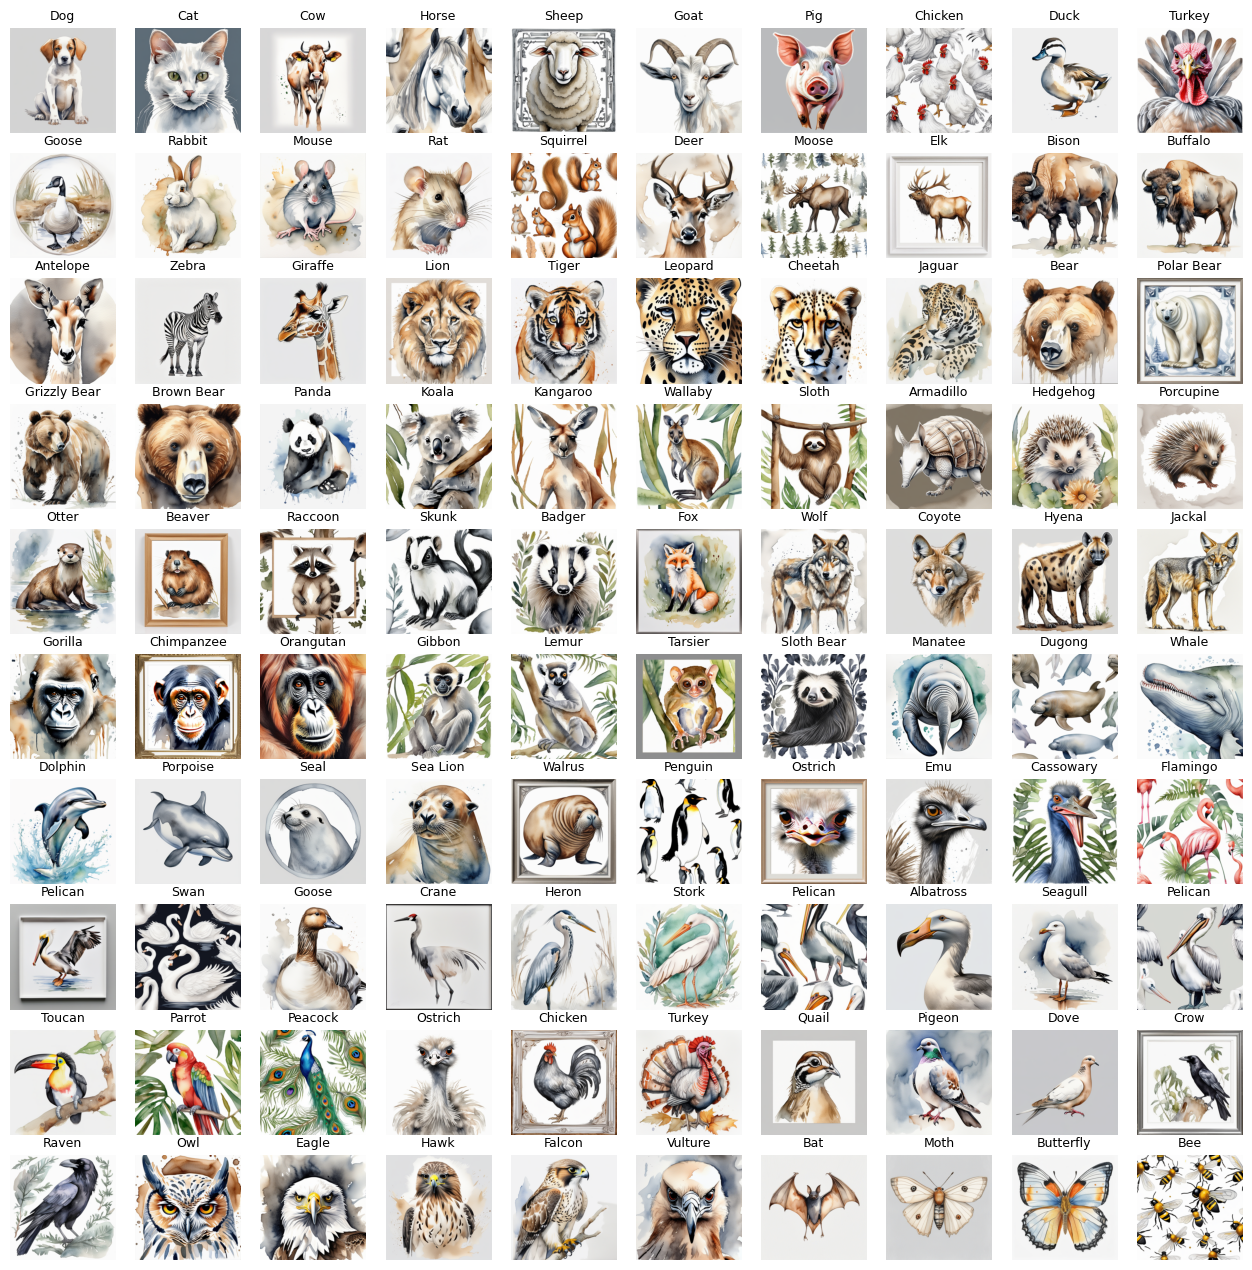

In [8]:
from mpl_toolkits.axes_grid1 import ImageGrid
import glob
import matplotlib.pyplot as plt

def display_image_grid(folder_path='.'):
    def find_images_glob(folder_path):
        image_files = []
        # You can specify multiple patterns for different image types
        image_files.extend(glob.glob(os.path.join(folder_path, '*thumb.png')))
        image_files.sort()
        images = [PIL.Image.open(image_file) for image_file in image_files]
        return images

    images = find_images_glob(folder_path)

    # Create a figure
    # figsize starts with width
    fig = plt.figure(figsize=(24., 16.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, 10), axes_pad=0.2)

    # Iterate over the grid and display images
    for ax, im in zip(grid[:len(images)], images):
        ax.imshow(im) # Ensure image data type is appropriate
        ax.axis('off') # Turn off axis labels and ticks
        word_and_num = ' '.join(os.path.splitext(os.path.basename(im.filename))[0].split('_')[:-1])
        word = ' '.join(word_and_num.split(" ")[1:])
        ax.set_title(f"{word}", fontsize=9)  # Set title to filename without extension
#        ax.set_title(f"{word[0]} - {word}", fontsize=9)  # Set title to filename without extension
#    for ax in grid[26:]:
#        ax.axis('off')
    plt.show()


display_image_grid(OUTPUT_DIR)

In [9]:
from PIL import Image, ImageDraw, ImageFont
import os, hashlib

# ---- New: font helpers ----
def _load_font(size: int):
    candidates = [
        "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",      # macOS
        "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/Library/Fonts/Arial.ttf",
        "DejaVuSans.ttf",  # packaged with Pillow
    ]
    for path in candidates:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    # last resort
    return ImageFont.load_default()

def _text_size(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.FreeTypeFont):
    # robust across Pillow versions
    bbox = draw.textbbox((0, 0), text, font=font)
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    return w, h

def _fit_font(draw, text, max_w, max_h, start=220, min_size=24):
    size = start
    while size >= min_size:
        font = _load_font(size)
        w, h = _text_size(draw, text, font)
        if w <= max_w and h <= max_h:
            return font
        size -= 4
    return _load_font(min_size)

# ---- Layout constants (unchanged poster size) ----
POSTER_W, POSTER_H = 7200, 10800
COLS, ROWS = 5, 6
MARGIN, GUTTER = 200, 60
CELL_W = (POSTER_W - 2*MARGIN - (COLS-1)*GUTTER) // COLS
CELL_H = (POSTER_H - 2*MARGIN - (ROWS-1)*GUTTER) // ROWS

# NEW: reserve a top label strip inside each cell
LABEL_H = 160              # pixels reserved for "A – Apple"
LABEL_PAD_X = 24
ICON_PAD = 40              # inner padding around the icon area

def _paste_icon(canvas, icon_path, box):
    x0, y0, x1, y1 = box
    # reduce available height by label strip
    x0i = x0 + ICON_PAD
    y0i = y0 + LABEL_H + ICON_PAD
    x1i = x1 - ICON_PAD
    y1i = y1 - ICON_PAD

    w = max(1, x1i - x0i)
    h = max(1, y1i - y0i)
    try:
        im = PIL.Image.open(icon_path).convert("RGBA")
        im.thumbnail((w, h), PIL.Image.LANCZOS)
        ox = x0i + (w - im.width) // 2
        oy = y0i + (h - im.height) // 2
        canvas.paste(im, (ox, oy), im)
        return True
    except Exception:
        return False

def _draw_label(draw, box, letter, noun):
    x0, y0, x1, y1 = box
    label = f"{letter}  –  {noun.title()}"
    max_w = (x1 - x0) - 2 * LABEL_PAD_X
    max_h = LABEL_H - 24

    font = _fit_font(draw, label, max_w=max_w, max_h=max_h, start=int(CELL_W * 0.12))
    w, h = _text_size(draw, label, font)

    tx = x0 + (x1 - x0 - w) // 2
    ty = y0 + (LABEL_H - h) // 2
    # optional: subtle shadow for readability
    draw.text((tx+2, ty+2), label, fill=(0,0,0,64), font=font)
    draw.text((tx, ty), label, fill=(0,0,0), font=font)

def _draw_placeholder(draw, box, letter, noun):
    x0, y0, x1, y1 = box
    # cell background
    draw.rounded_rectangle(box, radius=40, outline=(220,220,220), width=4, fill=(255,255,255))
    # label
    _draw_label(draw, box, letter, noun)
    # light “missing icon” hint in icon region
    ix0, iy0, ix1, iy1 = x0+ICON_PAD, y0+LABEL_H+ICON_PAD, x1-ICON_PAD, y1-ICON_PAD
    draw.rectangle((ix0, iy0, ix1, iy1), outline=(230,230,230), width=3)

def render_poster(nouns, out_png=OUTPUT_DIR / "alphabet_poster.png", out_pdf=OUTPUT_DIR / "alphabet_poster.pdf"):
    poster = Image.new("RGB", (POSTER_W, POSTER_H), "white")
    draw = ImageDraw.Draw(poster)

    def style_for_letter(ch: str) -> str:
        ch = ch.upper()
        return "vector" if "A" <= ch <= "I" else ("paper_cut" if "J" <= ch <= "R" else "clay")

    def safe(noun: str) -> str:
        return "".join(c if c.isalnum() or c in ("_","-"," ") else "_" for c in noun)

    for idx, noun in enumerate(nouns):
        if idx >= COLS * ROWS: break
        letter = noun[0].upper()
        style = style_for_letter(letter)
        # cell
        r, c = divmod(idx, COLS)
        x0 = MARGIN + c*(CELL_W+GUTTER); y0 = MARGIN + r*(CELL_H+GUTTER)
        x1, y1 = x0 + CELL_W, y0 + CELL_H
        draw.rounded_rectangle((x0,y0,x1,y1), radius=40, outline=(220,220,220), width=4, fill=(255,255,255))

        # icon
        path = OUTPUT_DIR / f"{safe(noun).strip().replace(' ','_')}.png" #_{style}.png")
        ok = _paste_icon(poster, path, (x0,y0,x1,y1))
        if not ok:
            _draw_placeholder(draw, (x0,y0,x1,y1), letter, noun)
        else:
            _draw_label(draw, (x0,y0,x1,y1), letter, noun)

    poster.save(out_png)
    try:
        poster.save(out_pdf, "PDF", resolution=300.0)
    except Exception:
        pass
    return { OUTPUT_DIR / "poster_png": out_png, OUTPUT_DIR / "poster_pdf": out_pdf }


In [10]:
# nouns A–Z (or your research agent’s list)
def find_nouns(folder_path):
    image_files = []
    # You can specify multiple patterns for different image types
    image_files.extend(glob.glob(os.path.join(folder_path, '*thumb.png')))
    image_files.sort()
    nouns = [x.split('/')[-1].split('_')[0] for x in image_files]
    return nouns

nouns = find_nouns(OUTPUT_DIR)

manifest = render_poster(nouns)  # writes alphabet_poster.png/.pdf


In [11]:
import inspect
if 0:
    obj=None # replace with function to learn more about
    print(inspect.signature(obj))                 # call signature
    print(inspect.signature(obj.__call__))        # tool-like callable
    print(inspect.getsource(obj.__call__))        # if it’s Python (not always)
    print(obj.__doc__)                            # often has the real param names
    print(dir(obj))                               # when docs are stale


## SDXL Tuning Guide: CFG vs Steps
### Quick definitions

CFG (guidance_scale) = how hard the model obeys the prompt
Higher = stricter prompt adherence, lower = more “freehand”/artistic drift.

Steps (num_inference_steps) = how long the denoising runs
Higher = more refinement/detail (up to a point), lower = faster/looser.

### Defaults that almost always work

Use these when you don’t want to think:

Size: 1024×1024 (generate big, downscale later)

Steps: 28–32

CFG: 5.5–6.5

### When to use LOWER CFG

#### Use low CFG (3.5–5.0) when you want:

softer watercolor vibe

less harsh outlines / less “sticker” look

more natural blending and wash texture

#### Tradeoff:
More drift: backgrounds creep in, extra objects appear, composition becomes less strict.

#### Typical use cases

dreamy landscapes

painterly “feel” matters more than precision

stylized backgrounds where “white isolation” is not required

### When to use HIGHER CFG

Use higher CFG (6.5–8.5) when you want:

strict composition (centered subject, single object)

accurate subject (the model must “follow instructions”)

fewer random additions (extra objects, scene elements)

#### Tradeoff:
Can look overcooked: harsh edges, artifacts, weird contrast, less watercolor softness.

#### Typical use cases

“single object on white background” flashcards

clean poster tiles

anything where prompt compliance > artistic freedom

Avoid: going above ~9 unless you like chaos.

### When to use FEWER steps

Use 15–25 steps when you want:

speed

looser, more impressionistic texture

quick iteration / exploration

#### Tradeoff:
Less structure and detail. Fur/feathers/edges can get mushy.

#### Typical use cases

rough drafts

generating tons of candidates fast (then re-run winners at higher steps)

### When to use MORE steps

Use 30–45 steps when you want:

cleaner edges

better facial features / anatomy

more consistent details

#### Tradeoff:
Slower and diminishing returns after ~40. Can get “busy” for watercolor.

#### Typical use cases

portraits (faces need refinement)

tight detail like uniforms, flags, symbols

final “hero” images

### Recommended presets by demo
1) Alphabet flashcards / isolated animals (your current project)

Goal: single subject, centered, plain white background.

Size: 1024×1024

Steps: 28–35

CFG: 6.0–7.5

Notes: Use strong negative prompt (no scenery/panels/text/duplicates). Downscale after.

If results are washed out: bump CFG slightly (6.5) or add “slightly bolder colors”.

2) Poster tiles of people (stylized portraits)

Goal: consistent face, recognizable, clean background.

Size: 768×1024 or 1024×1024

Steps: 32–45

CFG: 6.0–8.0

Notes: Faces benefit from more steps more than higher CFG.

If faces get weird: raise steps, not CFG.

3) Scene illustrations (maps, story images, landscapes)

Goal: aesthetics > strict instruction following.

Size: 1024×1024

Steps: 25–35

CFG: 4.0–6.0

Notes: Lower CFG reduces “poster cutout” vibe.

4) “Must be precise” (logos, diagrams, strict composition)

Goal: hard constraints. (Though SDXL isn’t perfect for diagrams.)

Size: 1024×1024

Steps: 30–40

CFG: 7.0–8.5

Notes: Strong negatives required. If it starts artifacting, reduce CFG slightly.

Symptoms → Fixes (fast debugging)
Too washed out / low contrast

Increase CFG by +0.5 to +1.5

Or add prompt phrase: “bolder colors, gentle contrast”

Don’t jump to 50 steps; that’s not the main fix.

Model adds background scenery

Increase CFG a bit

Strengthen negatives: “landscape, scenery, horizon, environment”

Add: “isolated cutout, pure white seamless background”

Duplicate subjects in one image (two animals, repeated copies)

Add negatives: “duplicates, multiple animals, pack, group, crowd”

Add prompt: “exactly ONE subject”

Edges are mushy / low detail

Increase steps to 32–40

Keep CFG moderate (5.5–7)

Looks overcooked / harsh outlines / weird artifacts

Reduce CFG by -1.0

Reduce steps slightly

Remove aggressive prompt phrases like “ultra sharp”

Practical production workflow

Generate at 1024×1024

Pick best candidates

Downscale to tile size (512×512 etc.)

Compose poster grid

This yields better “small tiles” than generating directly at tiny resolution.

Higher CFG is “follow the prompt harder.” Past a point, SDXL starts over-steering, and you get the visual equivalent of a driver yanking the wheel back and forth.

Here are the most common high-CFG artifacts you’ll see (especially >7–8):

1) Crunchy edges and harsh outlines

Subjects look like stickers cut out with scissors.

Watercolor loses softness.

Fur/feathers get over-defined.

2) Over-contrast / posterization

Smooth gradients turn into banding.

Shading looks “chunky,” like a limited color palette.

3) Weird texture amplification

Paper grain becomes too strong and starts looking like noise.

Skin/fur gets a speckled or “dirty” texture.

4) Repetitive micro-patterns

Strange striping, ribbing, or mottled patches.

Sometimes shows up in backgrounds as faint “scanlines.”

5) Anatomy distortion (counterintuitive but real)

Faces get uncanny: eyes/nose/mouth slightly off.

Animals get warped features.

It’s not “less accurate,” it’s “overconstrained to a bad local optimum.”

6) Prompt literalism / unwanted details

If you say “white background,” it may force:

bright halos

hard shadows

artificial studio lighting
instead of a clean watercolor cutout.

7) The “frame / border” problem

High CFG can latch onto “poster / illustration” and invent:

picture frames

vignette borders

faux paper edges

(That’s why strong negative prompts matter more as CFG rises.)

What high CFG is good for

Use higher CFG when you need:

single subject only

centered and isolated

fewer random extra objects

“must look like X”

But keep it in the “firm handshake” range, not “death grip.”

Rule of thumb

CFG 4–6: soft + pretty, but may drift

CFG 6–7.5: best balance

CFG 8+: artifact risk climbs fast

CFG 10+: “modern art roulette”

One super practical trick

Instead of cranking CFG, add one sentence of constraint:

“Exactly one subject. No duplicates. No extra objects. Pure white background.”

That often beats pushing CFG into artifact territory.

The core idea

CFG decides where you’re trying to go (how tightly you follow the text)

Steps decide how far you travel (how much the image gets refined)

So if CFG is weak, the model is basically “wandering.” More steps just gives it more time to wander confidently.

Your combos, in plain English
✅ High steps + low CFG = “confident drift”

This is the funky zone.

The model isn’t strongly anchored to your prompt…

…but it has plenty of steps to fully develop whatever random direction it chose early.

Result: coherent image, wrong idea. Often pretty. Often not your request.

Think: “it made something… it just wasn’t my thing.”

✅ Low steps + low CFG = “underbaked drift”

This is more ‘meh’ than ‘WTF’.

It drifts, but it doesn’t have enough iterations to turn that drift into a polished alternate universe.

Result: mushy / vague / incomplete… sometimes still off-target.

Think: “it forgot to finish loading.”

Bonus: High steps + high CFG = “overcooked obedience”

This is where you get:

harsh outlines

artifacts

crunchy textures

sticker vibes

Think: “it followed the rules… angrily.”

Bonus: Low steps + high CFG = “tight but sloppy”

It tries hard to obey prompt constraints…

but doesn’t have time to clean it up.

Result: on-topic composition, but rough details.

Think: “right answer, messy handwriting.”

One sentence summary

Low CFG = drift risk. High steps = drift gets fully realized.

So yes: 50 steps + low CFG is a recipe for “funky but detailed.”
And low steps + low CFG is more like “drifty but undercooked.”

Practical sweet spot for your flashcards

For “single animal on white background”:

CFG: 5.5–7.0

Steps: 28–35

If it drifts: raise CFG a bit or strengthen negatives.
If it’s crunchy: lower CFG a bit.